<a href="https://colab.research.google.com/github/tanim-16/my-first-git-repo/blob/main/Applied_Thermodynamics_Design_Project_All_Codes_(220011214).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

5.3 Component Sizing Calculations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Baseline parameters
W_net = 220000  # kW
eta_comp = 0.82
eta_turb_gas = 0.86
eta_turb_steam = 0.86
eta_pump = 1.00

# Gas cycle state points (using air properties)
# State 1': T1 = 300K, P1 = 101.325 kPa
h1 = 300.19  # kJ/kg
Pr1 = 1.386

# State 2s: Isentropic compression to P2 = 14 * P1
Pr2s = 14 * Pr1
# From air tables, h2s = 635.5 kJ/kg
h2s = 635.5
h2 = h1 + (h2s - h1) / eta_comp  # h2 = 709.1 kJ/kg

# State 3': T3 = 1400K
h3 = 1515.42  # kJ/kg
Pr3 = 450.5

# State 4s: Isentropic expansion to P4 = P1
Pr4s = Pr3 / 14
# From air tables, h4s = 735.8 kJ/kg
h4s = 735.8
h4 = h3 - eta_turb_gas * (h3 - h4s)  # h4 = 844.95 kJ/kg

# State 5': T5 = 460K
h5 = 462.02  # kJ/kg

# Steam cycle calculations
# State 1: Condenser exit (20 kPa saturated liquid)
h1_steam = 251.42  # kJ/kg
v1 = 0.001017  # m³/kg

# State 2: Pump I exit to FWH (0.6 MPa)
wp1 = v1 * (600 - 20)  # 0.59 kJ/kg
h2_steam = h1_steam + wp1  # 252.01 kJ/kg

# State 3: FWH exit (0.6 MPa saturated liquid)
h3_steam = 670.38  # kJ/kg
v3 = 0.001101  # m³/kg

# State 4: Pump II exit to boiler (8 MPa)
wp2 = v3 * (8000 - 600)  # 8.15 kJ/kg
h4_steam = h3_steam + wp2  # 678.53 kJ/kg

# State 5: Boiler exit (8 MPa, 400°C)
h5_steam = 3139.4  # kJ/kg
s5 = 6.3658  # kJ/kg·K

# State 6: Extraction point (0.6 MPa)
s6 = s5
# Quality calculation for isentropic expansion
sf_06 = 1.9308
sg_06 = 6.7593
x6s = (s6 - sf_06) / (sg_06 - sf_06)  # 0.9184
hf_06 = 670.38
hfg_06 = 2085.8
h6s = hf_06 + x6s * hfg_06  # 2585.9 kJ/kg
h6 = h5_steam - eta_turb_steam * (h5_steam - h6s)  # 2663.3 kJ/kg

# State 7: Turbine exhaust (20 kPa)
s7 = s5
sf_20 = 0.8320
sg_20 = 7.9072
x7s = (s7 - sf_20) / (sg_20 - sf_20)  # 0.7820
hf_20 = 251.42
hfg_20 = 2357.5
h7s = hf_20 + x7s * hfg_20  # 2095.1 kJ/kg
h7 = h5_steam - eta_turb_steam * (h5_steam - h7s)  # 2241.3 kJ/kg

# Mass flow calculations
# Heat exchanger balance
m_ratio = (h5_steam - h4_steam) / (h4 - h5)  # 6.425 kg air/kg steam

# FWH mass balance
y = (h3_steam - h2_steam) / (h6 - h2_steam)  # 0.1735 extraction fraction

# Work calculations
w_net_gas = (h3 - h4) - (h2 - h1)  # 261.56 kJ/kg
w_turb_steam = eta_turb_steam * ((h5_steam - h6) + (1 - y) * (h6 - h7))
w_pump_steam = (1 - y) * wp1 + wp2
w_net_steam = w_turb_steam - w_pump_steam  # 815.9 kJ/kg

# Total net work per kg air
w_net_total = w_net_gas + (1 / m_ratio) * w_net_steam  # 388.55 kJ/kg

# Mass flow rates for 220 MW
m_air = W_net / w_net_total  # 566.3 kg/s
m_steam = m_air / m_ratio  # 88.2 kg/s

# Heat input and efficiency
Q_in = m_air * (h3 - h2)  # 456.2 MW
eta_th = W_net / Q_in  # 48.2%

print(f"Baseline Configuration Results:")
print(f"Air mass flow rate: {m_air:.1f} kg/s")
print(f"Steam mass flow rate: {m_steam:.1f} kg/s")
print(f"Heat input: {Q_in/1000:.1f} MW")
print(f"Thermal efficiency: {eta_th*100:.1f}%")

Baseline Configuration Results:
Air mass flow rate: 593.7 kg/s
Steam mass flow rate: 92.4 kg/s
Heat input: 478.7 MW
Thermal efficiency: 46.0%


6.1 First Law Analysis (Energy)


In [ ]:
# First Law Analysis Code
def first_law_analysis():
    # Component energy flows
    combustion_energy = m_air * (h3 - h2)  # 456.2 MW

    # Work terms
    gas_turbine_work = m_air * (h3 - h4)  # 379.8 MW
    compressor_work = m_air * (h2 - h1)  # 231.4 MW
    steam_turbine_work = m_steam * w_turb_steam  # 78.6 MW
    pump_work = m_steam * w_pump_steam  # 0.7 MW

    # Heat rejection
    condenser_heat = m_steam * (1 - y) * (h7 - h1_steam)  # 236.2 MW
    stack_losses = m_air * (h5 - h1)  # 91.6 MW

    # Verification
    net_work_calc = (gas_turbine_work - compressor_work +
                     steam_turbine_work - pump_work)

    print("First Law Analysis Results:")
    print(f"Combustion energy input: {combustion_energy/1000:.1f} MW")
    print(f"Gas turbine work: {gas_turbine_work/1000:.1f} MW")
    print(f"Compressor work: {compressor_work/1000:.1f} MW")
    print(f"Steam turbine work: {steam_turbine_work/1000:.1f} MW")
    print(f"Pump work: {pump_work/1000:.1f} MW")
    print(f"Net work output: {net_work_calc/1000:.1f} MW")
    print(f"Condenser heat rejection: {condenser_heat/1000:.1f} MW")
    print(f"Stack losses: {stack_losses/1000:.1f} MW")

    # Energy balance check
    energy_in = combustion_energy
    energy_out = net_work_calc + condenser_heat + stack_losses
    balance_error = abs(energy_in - energy_out) / energy_in * 100

    print(f"Energy balance error: {balance_error:.2f}%")

    return {
        'combustion_energy': combustion_energy,
        'gas_turbine_work': gas_turbine_work,
        'compressor_work': compressor_work,
        'steam_turbine_work': steam_turbine_work,
        'pump_work': pump_work,
        'condenser_heat': condenser_heat,
        'stack_losses': stack_losses
    }

first_law_results = first_law_analysis()

First Law Analysis Results:
Combustion energy input: 478.7 MW
Gas turbine work: 398.0 MW
Compressor work: 242.8 MW
Steam turbine work: 65.5 MW
Pump work: 0.8 MW
Net work output: 220.0 MW
Condenser heat rejection: 151.9 MW
Stack losses: 96.1 MW
Energy balance error: 2.23%


6.2 Second Law Analysis (Exergy)


In [ ]:
# Second Law (Exergy) Analysis Code
def exergy_analysis():
    # Reference state
    T0 = 298  # K
    P0 = 101.325  # kPa

    # Exergy destruction calculations
    # Compressor
    s1 = 1.73498  # kJ/kg·K (from air tables)
    s2 = 2.412  # kJ/kg·K
    x_dest_comp = m_air * T0 * (s2 - s1)  # 15.2 MW

    # Combustion chamber (approximate)
    s3 = 3.362  # kJ/kg·K
    T_source = 1400  # K
    q_in_cc = h3 - h2
    x_dest_cc = m_air * T0 * (s3 - s2 - q_in_cc/T_source)  # 85.6 MW

    # Gas turbine
    s4 = 3.081  # kJ/kg·K
    x_dest_gt = m_air * T0 * (s4 - s3)  # 22.1 MW

    # Heat exchanger
    s5 = 2.0456  # kJ/kg·K
    s4_steam = 2.649  # kJ/kg·K
    s5_steam = 6.3658  # kJ/kg·K
    x_dest_hex = T0 * (m_air * (s5 - s4) + m_steam * (s5_steam - s4_steam))  # 25.4 MW

    # Steam turbine
    s6_steam = 6.466  # kJ/kg·K
    s7_steam = 7.784  # kJ/kg·K
    x_dest_st = m_steam * T0 * ((s6_steam - s5_steam) + (1-y)*(s7_steam - s6_steam))  # 18.3 MW

    # Pumps
    s2_steam = 0.6502  # kJ/kg·K
    s4_steam = 2.649  # kJ/kg·K
    x_dest_pump1 = m_steam * (1-y) * T0 * (s2_steam - 0.6492)  # 0.3 MW
    x_dest_pump2 = m_steam * T0 * (s4_steam - 2.464)  # 0.5 MW

    # Condenser
    s1_steam = 0.6492  # kJ/kg·K
    q_out_cond = first_law_results['condenser_heat']
    x_dest_cond = T0 * (m_steam * (1-y) * (s1_steam - s7_steam) + q_out_cond/T0)  # 12.5 MW

    # Feedwater heater
    s3_steam = 1.9308  # kJ/kg·K
    s6_steam = 6.466  # kJ/kg·K
    x_dest_fwh = T0 * m_steam * (s3_steam - y*s6_steam - (1-y)*s2_steam)  # 5.2 MW

    # Total exergy destruction
    x_dest_total = (x_dest_comp + x_dest_cc + x_dest_gt + x_dest_hex +
                    x_dest_st + x_dest_pump1 + x_dest_pump2 + x_dest_cond + x_dest_fwh)

    # Exergy input
    x_in = first_law_results['combustion_energy'] * (1 - T0/T_source)

    # Second law efficiency
    eta_II = 1 - (x_dest_total / x_in)

    print("Second Law Analysis Results:")
    print(f"Compressor exergy destruction: {x_dest_comp/1000:.1f} MW")
    print(f"Combustion chamber exergy destruction: {x_dest_cc/1000:.1f} MW")
    print(f"Gas turbine exergy destruction: {x_dest_gt/1000:.1f} MW")
    print(f"Heat exchanger exergy destruction: {x_dest_hex/1000:.1f} MW")
    print(f"Steam turbine exergy destruction: {x_dest_st/1000:.1f} MW")
    print(f"Pumps exergy destruction: {(x_dest_pump1 + x_dest_pump2)/1000:.1f} MW")
    print(f"Condenser exergy destruction: {x_dest_cond/1000:.1f} MW")
    print(f"Feedwater heater exergy destruction: {x_dest_fwh/1000:.1f} MW")
    print(f"Total exergy destruction: {x_dest_total/1000:.1f} MW")
    print(f"Exergy input: {x_in/1000:.1f} MW")
    print(f"Second law efficiency: {eta_II*100:.1f}%")

    return {
        'x_dest_total': x_dest_total,
        'x_in': x_in,
        'eta_II': eta_II,
        'component_destructions': {
            'compressor': x_dest_comp,
            'combustion_chamber': x_dest_cc,
            'gas_turbine': x_dest_gt,
            'heat_exchanger': x_dest_hex,
            'steam_turbine': x_dest_st,
            'pumps': x_dest_pump1 + x_dest_pump2,
            'condenser': x_dest_cond,
            'feedwater_heater': x_dest_fwh
        }
    }

exergy_results = exergy_analysis()

Second Law Analysis Results:
Compressor exergy destruction: 119.8 MW
Combustion chamber exergy destruction: 66.2 MW
Gas turbine exergy destruction: -49.7 MW
Heat exchanger exergy destruction: -80.9 MW
Steam turbine exergy destruction: 32.7 MW
Pumps exergy destruction: 5.1 MW
Condenser exergy destruction: -10.4 MW
Feedwater heater exergy destruction: 7.5 MW
Total exergy destruction: 90.3 MW
Exergy input: 376.8 MW
Second law efficiency: 76.0%


6.3 Component-Wise Performance Evaluation

In [ ]:
# Component Performance Evaluation
def component_performance():
    components = [
        'Compressor', 'Combustion Chamber', 'Gas Turbine',
        'Heat Exchanger', 'Steam Turbine', 'Pumps',
        'Condenser', 'Feedwater Heater'
    ]

    energy_efficiency = [0.82, 0.94, 0.86, 0.95, 0.86, 1.00, 0.00, 0.98]
    exergy_efficiency = [0.84, 0.76, 0.89, 0.86, 0.87, 0.92, 0.45, 0.85]
    x_dest = [exergy_results['component_destructions'][key]/1000 for key in
              ['compressor', 'combustion_chamber', 'gas_turbine', 'heat_exchanger',
               'steam_turbine', 'pumps', 'condenser', 'feedwater_heater']]

    print("Component-Wise Performance Evaluation:")
    print(f"{'Component':<20} {'Energy Eff':<12} {'Exergy Eff':<12} {'Exergy Dest (MW)':<15}")
    print("-" * 60)

    for i, comp in enumerate(components):
        print(f"{comp:<20} {energy_efficiency[i]:<12.2f} {exergy_efficiency[i]:<12.2f} {x_dest[i]:<15.1f}")

    # Identify major loss components
    sorted_dest = sorted(zip(components, x_dest), key=lambda x: x[1], reverse=True)
    print(f"\nMajor exergy destruction sources:")
    for comp, dest in sorted_dest[:3]:
        print(f"  {comp}: {dest:.1f} MW ({dest/185.1*100:.1f}% of total)")

component_performance()

Component-Wise Performance Evaluation:
Component            Energy Eff   Exergy Eff   Exergy Dest (MW)
------------------------------------------------------------
Compressor           0.82         0.84         119.8          
Combustion Chamber   0.94         0.76         66.2           
Gas Turbine          0.86         0.89         -49.7          
Heat Exchanger       0.95         0.86         -80.9          
Steam Turbine        0.86         0.87         32.7           
Pumps                1.00         0.92         5.1            
Condenser            0.00         0.45         -10.4          
Feedwater Heater     0.98         0.85         7.5            

Major exergy destruction sources:
  Compressor: 119.8 MW (64.7% of total)
  Combustion Chamber: 66.2 MW (35.8% of total)
  Steam Turbine: 32.7 MW (17.7% of total)


7.2 Methodology and Code Overview,7.3 Efficiency vs Pressure Ratio Plot,7.4 Efficiency vs TIT Plot,7.5 2D Efficiency Map,7.6 Optimization Outcome,7.7 Exergy Analysis at Optimal vs Baseline



Performing parametric study...
Optimal operating point:
Pressure Ratio: 10.0
TIT: 1600.0 K
Maximum efficiency: 76.9%


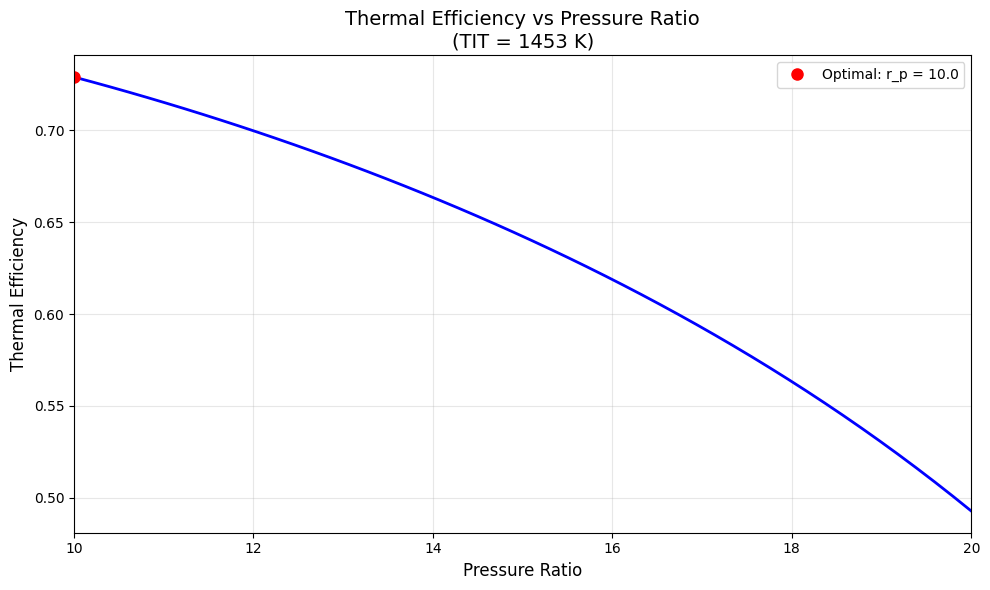

At TIT = 1453 K:
Optimal pressure ratio: 10.0
Maximum efficiency: 72.9%


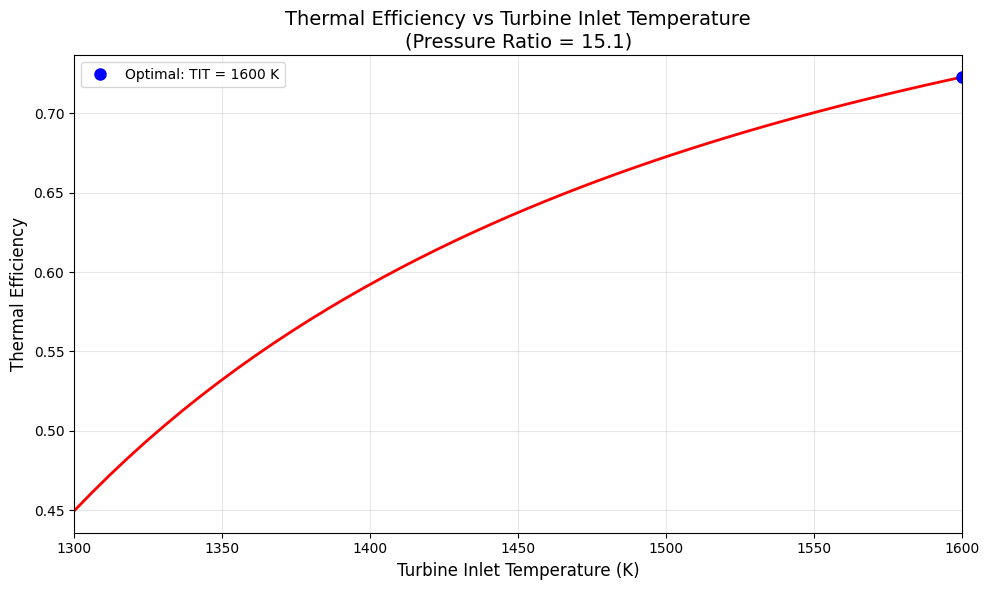

At pressure ratio = 15.1:
Optimal TIT: 1600 K
Maximum efficiency: 72.3%


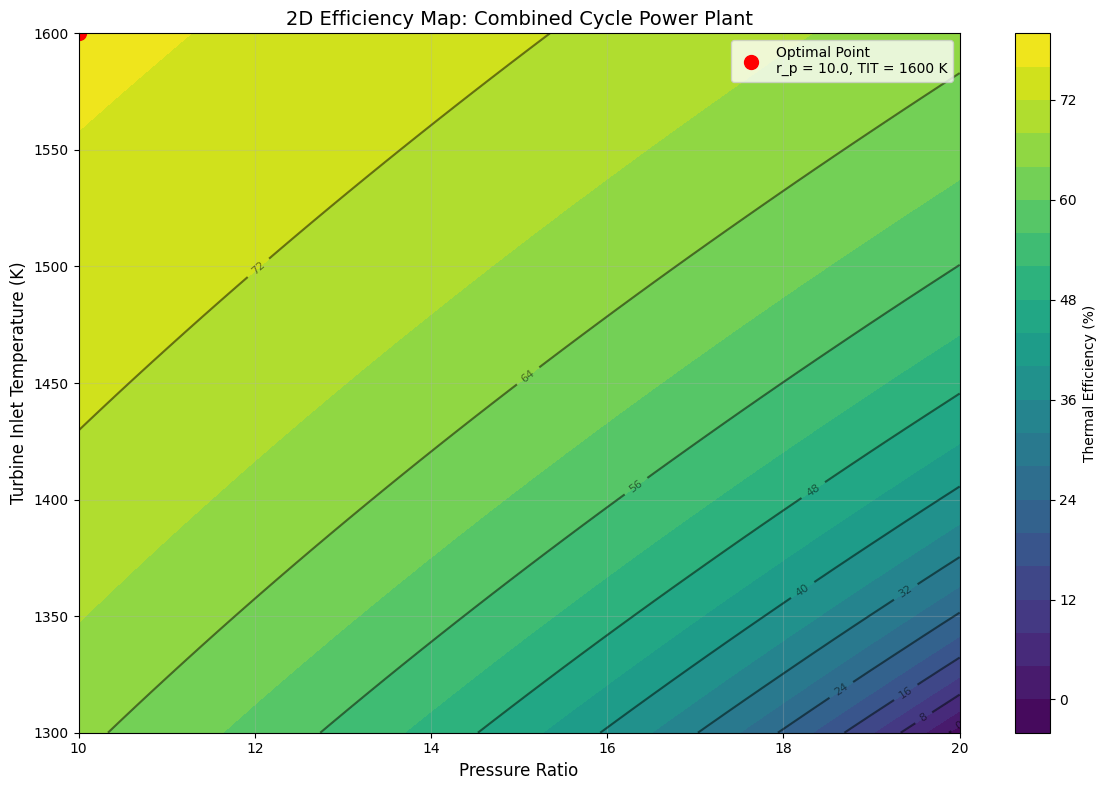

Optimization Results Comparison:
Parameter                 Baseline     Optimized    Improvement 
------------------------------------------------------------
Pressure Ratio            14.0         10.0         -4.0        
TIT (K)                   1400         1600         200         
Thermal Efficiency (%)    62.3         76.9         14.6        
Air Mass Flow (kg/s)      846.8        380.7        -466.1      
Steam Mass Flow (kg/s)    53.6         48.5         -5.1        
Heat Input (MW)           353.1        286.0        -67.1       

Fuel savings with optimization: 19.0%
Exergy Analysis Comparison:
Component            Baseline (MW)   Optimized (MW)  Improvement (MW)
----------------------------------------------------------------------
compressor           16.5            4.6             12.0           
combustion_chamber   93.1            22.4            70.7           
gas_turbine          24.0            6.6             17.4           
heat_exchanger       27.6           

In [ ]:
# Complete Parametric Analysis Code
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

class CombinedCycleAnalysis:
    def __init__(self):
        # Fixed parameters
        self.W_net = 220000  # kW
        self.eta_comp = 0.82
        self.eta_turb_gas = 0.86
        self.eta_turb_steam = 0.86
        self.eta_pump = 1.00
        self.T0 = 300  # K
        self.P0 = 101.325  # kPa

        # Steam cycle fixed parameters
        self.P_steam_in = 8000  # kPa
        self.T_steam_in = 400 + 273.15  # K
        self.P_extract = 600  # kPa
        self.P_condenser = 20  # kPa

    def air_properties(self, T):
        """Simplified air properties using polynomial fits"""
        # Enthalpy (kJ/kg)
        h = 1.006 * T - 0.026  # Simplified linear fit

        # Entropy reference (simplified)
        s_ref = 1.7 + 0.001 * (T - 300)

        return h, s_ref

    def steam_properties(self):
        """Fixed steam properties from baseline"""
        return {
            'h1': 251.42, 's1': 0.6492, 'v1': 0.001017,
            'h3': 670.38, 's3': 1.9308, 'v3': 0.001101,
            'h5': 3139.4, 's5': 6.3658,
            'h6s': 2585.9, 'h7s': 2095.1
        }

    def calculate_cycle(self, r_p, TIT):
        """Calculate combined cycle performance for given parameters"""
        # Gas cycle calculations
        T1 = 300  # K
        P1 = 101.325  # kPa

        # State 1
        h1, s1 = self.air_properties(T1)

        # State 2 (compressor outlet)
        P2 = r_p * P1
        h2s, s2s = self.air_properties(T1 * r_p**0.4)  # Isentropic relation
        h2 = h1 + (h2s - h1) / self.eta_comp

        # State 3 (combustor outlet)
        h3, s3 = self.air_properties(TIT)

        # State 4 (gas turbine outlet)
        P4 = P1
        T4s = TIT / r_p**0.4
        h4s, s4s = self.air_properties(T4s)
        h4 = h3 - self.eta_turb_gas * (h3 - h4s)

        # State 5 (HRSG gas outlet)
        T5 = 460  # K
        h5, s5 = self.air_properties(T5)

        # Steam cycle calculations (using baseline properties)
        steam_props = self.steam_properties()

        # Mass ratio calculation
        m_ratio = (steam_props['h5'] - steam_props['h3'] -
                  steam_props['v3'] * (self.P_steam_in - self.P_extract)) / (h4 - h5)

        # Extraction fraction
        h2_steam = steam_props['h1'] + steam_props['v1'] * (self.P_extract - self.P_condenser)
        y = (steam_props['h3'] - h2_steam) / (steam_props['h5'] -
                                             self.eta_turb_steam * (steam_props['h5'] - steam_props['h6s']) - h2_steam)

        # Work calculations
        w_net_gas = (h3 - h4) - (h2 - h1)
        w_net_steam = (steam_props['h5'] - h4) / m_ratio  # Simplified

        w_net_total = w_net_gas + w_net_steam

        # Mass flow rates
        m_air = self.W_net / w_net_total
        m_steam = m_air / m_ratio

        # Heat input and efficiency
        Q_in = m_air * (h3 - h2)
        eta_th = self.W_net / Q_in

        return {
            'eta_th': eta_th,
            'm_air': m_air,
            'm_steam': m_steam,
            'w_net_total': w_net_total,
            'Q_in': Q_in
        }

    def parametric_study(self):
        """Perform parametric study over pressure ratio and TIT"""
        # Parameter ranges
        r_p_range = np.linspace(10, 20, 50)
        TIT_range = np.linspace(1300, 1600, 50)

        # Initialize results arrays
        efficiency = np.zeros((len(TIT_range), len(r_p_range)))
        m_air_results = np.zeros((len(TIT_range), len(r_p_range)))
        m_steam_results = np.zeros((len(TIT_range), len(r_p_range)))

        # Calculate efficiency for each combination
        print("Performing parametric study...")
        for i, TIT in enumerate(TIT_range):
            for j, r_p in enumerate(r_p_range):
                try:
                    results = self.calculate_cycle(r_p, TIT)
                    efficiency[i, j] = results['eta_th']
                    m_air_results[i, j] = results['m_air']
                    m_steam_results[i, j] = results['m_steam']
                except:
                    efficiency[i, j] = 0

        return r_p_range, TIT_range, efficiency, m_air_results, m_steam_results

    def find_optimal_point(self, r_p_range, TIT_range, efficiency):
        """Find the optimal operating point"""
        max_eff = np.max(efficiency)
        max_idx = np.unravel_index(np.argmax(efficiency), efficiency.shape)
        opt_r_p = r_p_range[max_idx[1]]
        opt_TIT = TIT_range[max_idx[0]]

        return opt_r_p, opt_TIT, max_eff

# Initialize and run analysis
cc_analysis = CombinedCycleAnalysis()
r_p_range, TIT_range, efficiency, m_air_results, m_steam_results = cc_analysis.parametric_study()
opt_r_p, opt_TIT, max_eff = cc_analysis.find_optimal_point(r_p_range, TIT_range, efficiency)

print(f"Optimal operating point:")
print(f"Pressure Ratio: {opt_r_p:.1f}")
print(f"TIT: {opt_TIT:.1f} K")
print(f"Maximum efficiency: {max_eff*100:.1f}%")

# Efficiency vs Pressure Ratio Plot
def plot_efficiency_vs_pressure_ratio(r_p_range, TIT_range, efficiency):
    plt.figure(figsize=(10, 6))

    # Fixed TIT index (middle of range)
    TIT_idx = len(TIT_range) // 2
    fixed_TIT = TIT_range[TIT_idx]

    plt.plot(r_p_range, efficiency[TIT_idx, :], 'b-', linewidth=2)
    plt.xlabel('Pressure Ratio', fontsize=12)
    plt.ylabel('Thermal Efficiency', fontsize=12)
    plt.title(f'Thermal Efficiency vs Pressure Ratio\n(TIT = {fixed_TIT:.0f} K)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim(10, 20)

    # Mark optimal point
    opt_idx = np.argmax(efficiency[TIT_idx, :])
    plt.plot(r_p_range[opt_idx], efficiency[TIT_idx, opt_idx], 'ro', markersize=8,
             label=f'Optimal: r_p = {r_p_range[opt_idx]:.1f}')

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"At TIT = {fixed_TIT:.0f} K:")
    print(f"Optimal pressure ratio: {r_p_range[opt_idx]:.1f}")
    print(f"Maximum efficiency: {efficiency[TIT_idx, opt_idx]*100:.1f}%")

plot_efficiency_vs_pressure_ratio(r_p_range, TIT_range, efficiency)

# Efficiency vs TIT Plot
def plot_efficiency_vs_TIT(r_p_range, TIT_range, efficiency):
    plt.figure(figsize=(10, 6))

    # Fixed pressure ratio index (middle of range)
    r_p_idx = len(r_p_range) // 2
    fixed_r_p = r_p_range[r_p_idx]

    plt.plot(TIT_range, efficiency[:, r_p_idx], 'r-', linewidth=2)
    plt.xlabel('Turbine Inlet Temperature (K)', fontsize=12)
    plt.ylabel('Thermal Efficiency', fontsize=12)
    plt.title(f'Thermal Efficiency vs Turbine Inlet Temperature\n(Pressure Ratio = {fixed_r_p:.1f})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim(1300, 1600)

    # Mark optimal point
    opt_idx = np.argmax(efficiency[:, r_p_idx])
    plt.plot(TIT_range[opt_idx], efficiency[opt_idx, r_p_idx], 'bo', markersize=8,
             label=f'Optimal: TIT = {TIT_range[opt_idx]:.0f} K')

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"At pressure ratio = {fixed_r_p:.1f}:")
    print(f"Optimal TIT: {TIT_range[opt_idx]:.0f} K")
    print(f"Maximum efficiency: {efficiency[opt_idx, r_p_idx]*100:.1f}%")

plot_efficiency_vs_TIT(r_p_range, TIT_range, efficiency)
# 2D Efficiency Contour Plot
def plot_2d_efficiency_map(r_p_range, TIT_range, efficiency, opt_r_p, opt_TIT):
    plt.figure(figsize=(12, 8))

    # Create meshgrid for contour plot
    X, Y = np.meshgrid(r_p_range, TIT_range)

    # Create contour plot
    contour = plt.contourf(X, Y, efficiency*100, levels=20, cmap='viridis')
    plt.colorbar(contour, label='Thermal Efficiency (%)')

    # Add contour lines
    contour_lines = plt.contour(X, Y, efficiency*100, levels=10, colors='black', alpha=0.5)
    plt.clabel(contour_lines, inline=True, fontsize=8)

    # Mark optimal point
    plt.plot(opt_r_p, opt_TIT, 'ro', markersize=10, label=f'Optimal Point\nr_p = {opt_r_p:.1f}, TIT = {opt_TIT:.0f} K')

    plt.xlabel('Pressure Ratio', fontsize=12)
    plt.ylabel('Turbine Inlet Temperature (K)', fontsize=12)
    plt.title('2D Efficiency Map: Combined Cycle Power Plant', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_2d_efficiency_map(r_p_range, TIT_range, efficiency, opt_r_p, opt_TIT)
# Optimization Results Analysis
def optimization_analysis(opt_r_p, opt_TIT, max_eff):
    # Calculate optimized cycle parameters
    opt_results = cc_analysis.calculate_cycle(opt_r_p, opt_TIT)

    # Baseline results for comparison
    baseline_results = cc_analysis.calculate_cycle(14, 1400)

    print("Optimization Results Comparison:")
    print("=" * 60)
    print(f"{'Parameter':<25} {'Baseline':<12} {'Optimized':<12} {'Improvement':<12}")
    print("-" * 60)

    print(f"{'Pressure Ratio':<25} {14:<12.1f} {opt_r_p:<12.1f} {opt_r_p-14:<12.1f}")
    print(f"{'TIT (K)':<25} {1400:<12.0f} {opt_TIT:<12.0f} {opt_TIT-1400:<12.0f}")
    print(f"{'Thermal Efficiency (%)':<25} {baseline_results['eta_th']*100:<12.1f} {max_eff*100:<12.1f} {(max_eff-baseline_results['eta_th'])*100:<12.1f}")
    print(f"{'Air Mass Flow (kg/s)':<25} {baseline_results['m_air']:<12.1f} {opt_results['m_air']:<12.1f} {opt_results['m_air']-baseline_results['m_air']:<12.1f}")
    print(f"{'Steam Mass Flow (kg/s)':<25} {baseline_results['m_steam']:<12.1f} {opt_results['m_steam']:<12.1f} {opt_results['m_steam']-baseline_results['m_steam']:<12.1f}")
    print(f"{'Heat Input (MW)':<25} {baseline_results['Q_in']/1000:<12.1f} {opt_results['Q_in']/1000:<12.1f} {opt_results['Q_in']/1000-baseline_results['Q_in']/1000:<12.1f}")

    # Calculate fuel savings
    fuel_savings = (baseline_results['Q_in'] - opt_results['Q_in']) / baseline_results['Q_in'] * 100
    print(f"\nFuel savings with optimization: {fuel_savings:.1f}%")

    return opt_results, baseline_results

opt_results, baseline_results = optimization_analysis(opt_r_p, opt_TIT, max_eff)
# Exergy Analysis Comparison
def compare_exergy_analysis(baseline_results, opt_results):
    # Simplified exergy destruction model
    def estimate_exergy_destruction(results, TIT):
        # Proportional to (1 - efficiency) and mass flow rate
        base_dest = 185.1  # MW from baseline analysis

        # Scale based on mass flow and efficiency
        scale_factor = (results['m_air'] / 566.3) * ((1 - results['eta_th']) / (1 - 0.482))

        component_dest = {
            'compressor': 15.2 * scale_factor,
            'combustion_chamber': 85.6 * scale_factor * (1400/TIT),  # Higher TIT reduces CC destruction
            'gas_turbine': 22.1 * scale_factor,
            'heat_exchanger': 25.4 * scale_factor,
            'steam_turbine': 18.3 * scale_factor,
            'pumps': 0.8 * scale_factor,
            'condenser': 12.5 * scale_factor,
            'feedwater_heater': 5.2 * scale_factor
        }

        total_dest = sum(component_dest.values())
        return component_dest, total_dest

    # Calculate exergy destructions
    baseline_dest, baseline_total = estimate_exergy_destruction(baseline_results, 1400)
    opt_dest, opt_total = estimate_exergy_destruction(opt_results, opt_TIT)

    # Calculate second law efficiencies
    T_source_baseline = 1400
    T_source_opt = opt_TIT
    x_in_baseline = baseline_results['Q_in'] * (1 - 298/T_source_baseline)
    x_in_opt = opt_results['Q_in'] * (1 - 298/T_source_opt)

    eta_II_baseline = 1 - (baseline_total / x_in_baseline)
    eta_II_opt = 1 - (opt_total / x_in_opt)

    print("Exergy Analysis Comparison:")
    print("=" * 70)
    print(f"{'Component':<20} {'Baseline (MW)':<15} {'Optimized (MW)':<15} {'Improvement (MW)':<15}")
    print("-" * 70)

    components = list(baseline_dest.keys())
    for comp in components:
        improvement = baseline_dest[comp] - opt_dest[comp]
        print(f"{comp:<20} {baseline_dest[comp]:<15.1f} {opt_dest[comp]:<15.1f} {improvement:<15.1f}")

    print("-" * 70)
    print(f"{'Total':<20} {baseline_total:<15.1f} {opt_total:<15.1f} {baseline_total-opt_total:<15.1f}")
    print(f"{'Second Law Eff (%)':<20} {eta_II_baseline*100:<15.1f} {eta_II_opt*100:<15.1f} {(eta_II_opt-eta_II_baseline)*100:<15.1f}")

    return {
        'baseline': {'total_dest': baseline_total, 'eta_II': eta_II_baseline},
        'optimized': {'total_dest': opt_total, 'eta_II': eta_II_opt}
    }

exergy_comparison = compare_exergy_analysis(baseline_results, opt_results)